# Pneumonia em raio-X de tórax com rede convolucional

Segunda tentativa no mesmo problema do notebook `aprendizadado-maquina-imagem.ipynb`.
Lá a decisão foi **descrever a imagem à mão** — mediana, Sobel, média ponderada — e
jogar o vetor resultante numa MLP. Deu 77% de acurácia no teste, e o diagnóstico do
repasse (`REPASSE.md`) foi que o gargalo não era a rede: era o descritor. Filtro de
borda fixo não sabe o que é opacidade alveolar.

A convolução resolve isso invertendo quem escolhe o filtro. Em vez de eu decidir que
Sobel é o que importa, a rede começa com filtros aleatórios e o gradiente os empurra
para o que reduz a perda. É o mesmo backpropagation da MLP; o que muda é que os pesos
agora são **kernels deslizantes**, compartilhados por toda a imagem. Duas consequências
práticas:

- **Muito menos parâmetros.** Uma camada densa ligando 128×128 pixels a 32 neurônios
  precisa de 524 mil pesos. Trinta e dois kernels 3×3 precisam de 288. O mesmo detector
  de borda serve para o canto superior esquerdo e para o centro do pulmão.
- **Invariância a translação.** Se a opacidade aparece dois centímetros mais à direita,
  o mesmo kernel dispara — só que num outro ponto do mapa de ativação. A MLP sobre
  pixels crus teria que reaprender o padrão em cada posição.

## O que este notebook faz de diferente

O `REPASSE.md` terminou com uma lista de "se for continuar". Três itens dela viram
experimento aqui, e o notebook é montado em torno dessa comparação:

| | pré-processamento | aumento de dados |
|---|---|---|
| **A — bruto** | divisão por 255 | não |
| **B — aumento** | divisão por 255 | sim |
| **C — clahe** | CLAHE + divisão por 255 | sim |

Mesma arquitetura, mesma semente, mesma divisão dos dados nas três. A única coisa que
muda é **o que acontece com a imagem antes de entrar na rede** — que era exatamente a
suspeita do repasse: o abismo entre 3% de erro na validação e 23% no teste vem de
diferença de aquisição entre as pastas, e o que ataca isso é normalizar por imagem em
vez de por pixel.

**Convenção de rótulo:** `0 = NORMAL`, `1 = PNEUMONIA`. A classe positiva é o doente,
então *recall* alto significa "quase não deixa passar pneumonia" — que é a métrica que
importa aqui, não a acurácia.

## 1. Ambiente

In [1]:
%matplotlib inline
import os
import time
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, roc_auc_score)

SEMENTE = 7
random.seed(SEMENTE)
np.random.seed(SEMENTE)
torch.manual_seed(SEMENTE)

# MPS = GPU integrada dos Macs Apple Silicon. Cai para CPU em qualquer outra maquina.
DISPOSITIVO = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print("torch      ", torch.__version__)
print("dispositivo", DISPOSITIVO)

torch       2.12.1
dispositivo mps


> **Cuidado com MPS:** ele não implementa `float64`. Todo tensor que for para o
> dispositivo precisa ser `float32` — por isso os `.float()` explícitos mais adiante.
> `numpy` promove para `float64` na primeira divisão descuidada, e o erro que aparece
> lá na frente não menciona a linha que causou.

## 2. Os dados

Dataset [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia):
radiografias de tórax em incidência ântero-posterior, de pacientes pediátricos de 1 a 5
anos do Guangzhou Women and Children's Medical Center. Cada imagem foi laudada por dois
médicos, e o conjunto de teste passou por um terceiro.

**As imagens não estão no repositório** (~1,2 GB). Ajuste `PASTA_DADOS` abaixo para
onde elas estiverem. A pasta `val/` original tinha 8 + 8 imagens — pouco demais para
escolher hiperparâmetro — e foi absorvida pelo `train/`; a validação aqui é um recorte
de 20% do próprio `train/`.

In [2]:
PASTA_DADOS = os.environ.get(
    "PASTA_RAIOX", "/Users/icaroamerico/Documents/imagens_fase_1_pos_fiap"
)
CLASSES = ["NORMAL", "PNEUMONIA"]   # o indice na lista e o rotulo: NORMAL=0, PNEUMONIA=1
EXTENSOES = (".jpeg", ".jpg", ".png")


def lista_arquivos(particao, classe):
    """Caminhos das imagens de uma classe, ja filtrando .DS_Store e afins."""
    pasta = os.path.join(PASTA_DADOS, particao, classe)
    nomes = sorted(n for n in os.listdir(pasta) if n.lower().endswith(EXTENSOES))
    return [os.path.join(pasta, n) for n in nomes]


inventario = pd.DataFrame(
    [{"particao": p, "classe": c, "imagens": len(lista_arquivos(p, c))}
     for p in ("train", "test") for c in CLASSES]
).pivot(index="particao", columns="classe", values="imagens")

inventario["total"] = inventario.sum(axis=1)
inventario["%_pneumonia"] = (100 * inventario["PNEUMONIA"] / inventario["total"]).round(1)
inventario

classe,NORMAL,PNEUMONIA,total,%_pneumonia
particao,,,,
test,234,390,624,62.5
train,1349,3883,5232,74.2


Duas coisas para guardar desta tabela, porque as duas voltam no fim:

1. **O treino é desbalanceado**: 74% pneumonia. Uma rede preguiçosa que responda sempre
   "pneumonia" já acerta 74% no treino — e a perda vai cair, dando a impressão de que
   está aprendendo.
2. **O teste é desbalanceado de forma diferente**: 62,5%. As duas pastas não são
   amostras da mesma população; o `test/` foi curado à parte. É por isso que o número
   que vale é sempre o do `test/`, e que a linha de base a bater é **62,5%**, não 50%.

## 3. Exploração

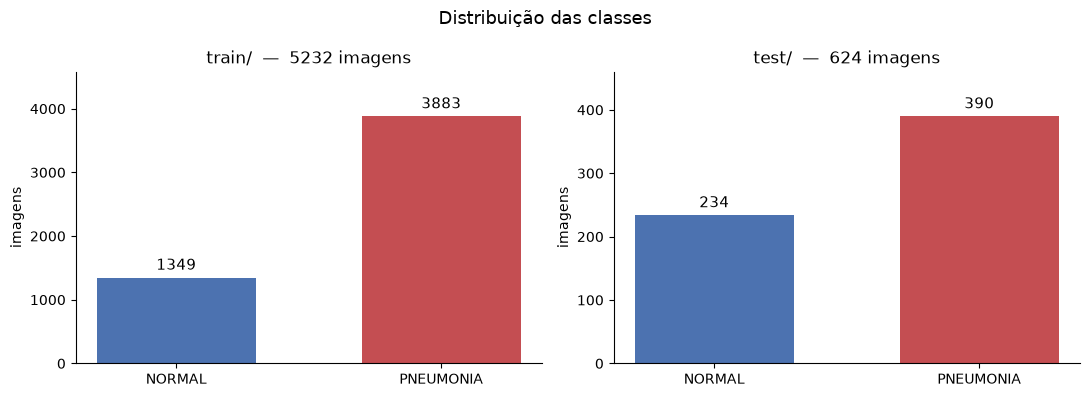

In [3]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))

for eixo, particao in zip(eixos, ("train", "test")):
    alturas = [inventario.loc[particao, c] for c in CLASSES]
    barras = eixo.bar(CLASSES, alturas, color=["#4C72B0", "#C44E52"], width=0.6)
    eixo.bar_label(barras, padding=3, fontsize=11)
    eixo.set_title(f"{particao}/  —  {inventario.loc[particao, 'total']} imagens")
    eixo.set_ylabel("imagens")
    eixo.set_ylim(0, max(alturas) * 1.18)
    eixo.spines[["top", "right"]].set_visible(False)

fig.suptitle("Distribuição das classes", fontsize=13)
fig.tight_layout()
plt.show()

**Como são as imagens.** Quatro de cada classe, direto do disco, sem nenhum tratamento:

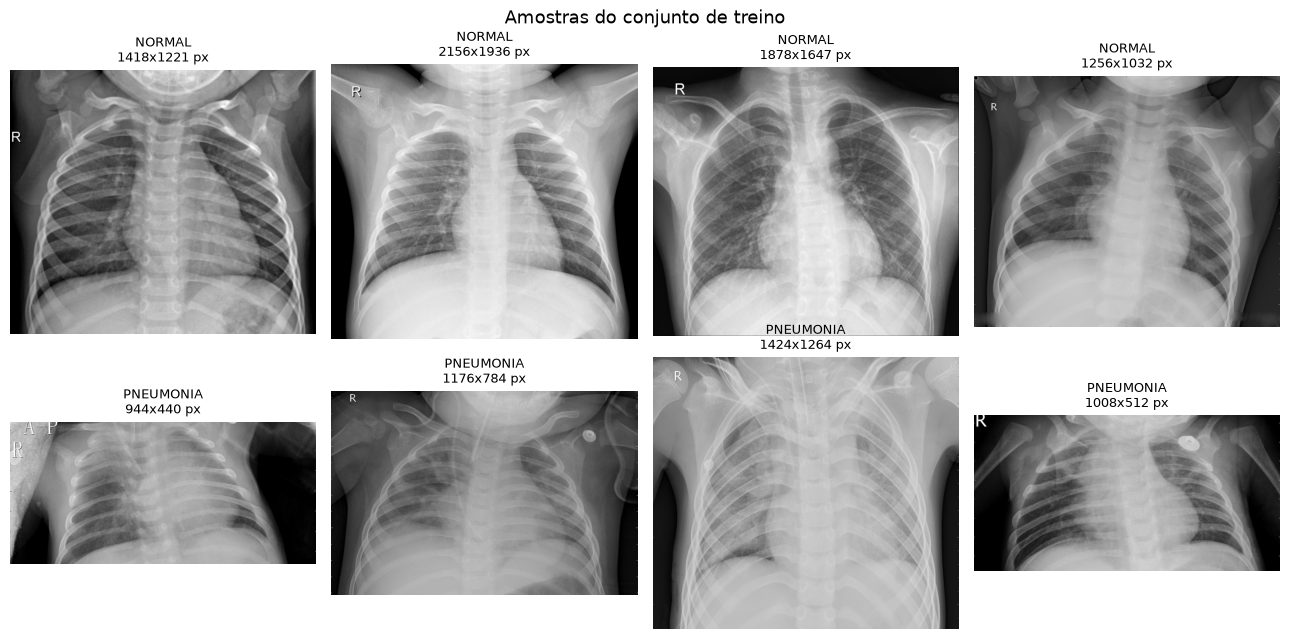

In [4]:
fig, eixos = plt.subplots(2, 4, figsize=(13, 6.5))

for linha, classe in enumerate(CLASSES):
    caminhos = lista_arquivos("train", classe)
    sorteio = random.Random(SEMENTE).sample(caminhos, 4)
    for coluna, caminho in enumerate(sorteio):
        imagem = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
        eixo = eixos[linha, coluna]
        eixo.imshow(imagem, cmap="gray")
        eixo.set_title(f"{classe}\n{imagem.shape[1]}x{imagem.shape[0]} px", fontsize=9)
        eixo.axis("off")

fig.suptitle("Amostras do conjunto de treino", fontsize=13)
fig.tight_layout()
plt.show()

A olho nu a diferença existe mas é sutil: nas pneumonias o pulmão aparece mais
"esbranquiçado" e com contornos borrados nas bases — é o infiltrado. Nas normais o
campo pulmonar é escuro e uniforme, e dá para seguir a trama vascular.

Note também que **as imagens não têm tamanho nem contraste padronizados**. Isso é
diretamente o que motiva o experimento com CLAHE.

In [5]:
# Dimensoes e brilho: uma amostra de 200 por classe basta para ver a dispersao.
registros = []
for particao in ("train", "test"):
    for classe in CLASSES:
        caminhos = lista_arquivos(particao, classe)
        for caminho in random.Random(SEMENTE).sample(caminhos, min(200, len(caminhos))):
            imagem = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
            registros.append({
                "particao": particao, "classe": classe,
                "largura": imagem.shape[1], "altura": imagem.shape[0],
                "brilho": imagem.mean(), "contraste": imagem.std(),
            })

amostra = pd.DataFrame(registros)
amostra.groupby("classe")[["largura", "altura", "brilho", "contraste"]].describe().T.round(1)

classe           NORMAL  PNEUMONIA
largura   count   400.0      400.0
          mean   1737.6     1190.5
          std     336.6      270.1
          min     984.0      415.0
          25%    1472.0     1006.0
          50%    1727.0     1152.0
          75%    1937.0     1328.5
          max    2752.0     2258.0
altura    count   400.0      400.0
          mean   1385.5      811.4
          std     386.3      262.6
          min     496.0      167.0
          25%    1103.8      648.0
          50%    1325.5      752.0
          75%    1619.2      930.0
          max    2578.0     2109.0
brilho    count   400.0      400.0
          mean    124.2      120.6
          std      14.9       19.8
          min      80.1       58.7
          25%     113.8      109.0
          50%     123.7      121.0
          75%     132.9      133.8
          max     169.6      170.6
contraste count   400.0      400.0
          mean     60.7       55.4
          std       6.3        9.4
          min      33.0       25.4
          25%      56.9       49.2
          50%      61.3       54.6
          75%      64.6       61.7
          max      77.7       82.7

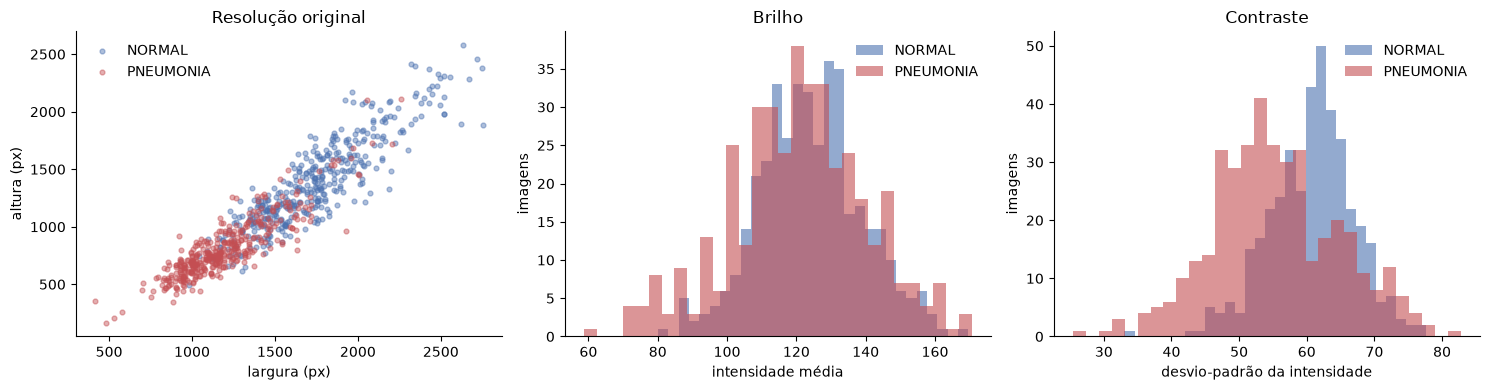

In [6]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))

cores = {"NORMAL": "#4C72B0", "PNEUMONIA": "#C44E52"}

for classe in CLASSES:
    recorte = amostra[amostra.classe == classe]
    eixos[0].scatter(recorte.largura, recorte.altura, s=12, alpha=0.45,
                     label=classe, color=cores[classe])
    eixos[1].hist(recorte.brilho, bins=30, alpha=0.6, label=classe, color=cores[classe])
    eixos[2].hist(recorte.contraste, bins=30, alpha=0.6, label=classe, color=cores[classe])

eixos[0].set(xlabel="largura (px)", ylabel="altura (px)", title="Resolução original")
eixos[1].set(xlabel="intensidade média", ylabel="imagens", title="Brilho")
eixos[2].set(xlabel="desvio-padrão da intensidade", ylabel="imagens", title="Contraste")

for eixo in eixos:
    eixo.legend(frameon=False)
    eixo.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

O painel da esquerda mostra o problema de enquadramento: a resolução varia de umas
poucas centenas a mais de 2000 px, e a proporção largura/altura não é constante.
Redimensionar tudo para um quadrado distorce, mas é o preço de ter lotes de tamanho fixo.

Os dois painéis da direita mostram o problema de aquisição: brilho e contraste se
espalham por uma faixa larga **dentro de cada classe**. Uma parte dessa variação é
aparelho e exposição, não patologia — e é exatamente o tipo de sinal espúrio que a rede
pode aprender no lugar do achado clínico. Daí a configuração C.

## 4. Carga e divisão

Resolução de trabalho: **128×128, tons de cinza**. O repasse projetou que 128×128 caberia
na memória desta máquina, e cabe: 5232 imagens em `uint8` ocupam 86 MB. A conversão para
`float32` acontece por lote, dentro do laço de treino, e nunca sobre a matriz inteira —
foi essa promoção para `float64` sobre a matriz toda que travava o notebook da MLP.

In [7]:
LADO = 128


def carrega_particao(particao):
    """Le uma particao inteira para um array uint8 (N, LADO, LADO) e os rotulos."""
    pixels, rotulos = [], []
    for rotulo, classe in enumerate(CLASSES):
        for caminho in lista_arquivos(particao, classe):
            imagem = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
            if imagem is None:          # arquivo corrompido: pula em vez de quebrar
                continue
            # INTER_AREA e o reamostrador correto para reduzir: faz a media dos pixels
            # que colapsam, em vez de sortear um deles como o INTER_LINEAR.
            pixels.append(cv2.resize(imagem, (LADO, LADO), interpolation=cv2.INTER_AREA))
            rotulos.append(rotulo)
    return np.stack(pixels), np.array(rotulos, dtype=np.float32)


relogio = time.time()
pixels_completo, rotulos_completo = carrega_particao("train")
pixels_teste, rotulos_teste = carrega_particao("test")

print(f"carga concluida em {time.time() - relogio:.0f}s")
print(f"train  {pixels_completo.shape}  {pixels_completo.nbytes / 1e6:.0f} MB")
print(f"test   {pixels_teste.shape}  {pixels_teste.nbytes / 1e6:.0f} MB")

carga concluida em 57s
train  (5232, 128, 128)  86 MB
test   (624, 128, 128)  10 MB


In [8]:
# Divisao estratificada: as duas metades preservam a proporcao 74/26 do original.
pixels_treino, pixels_val, rotulos_treino, rotulos_val = train_test_split(
    pixels_completo, rotulos_completo,
    test_size=0.20, stratify=rotulos_completo, random_state=SEMENTE,
)

divisao = pd.DataFrame({
    "conjunto": ["treino", "validação", "teste"],
    "imagens": [len(rotulos_treino), len(rotulos_val), len(rotulos_teste)],
    "% pneumonia": [round(100 * float(r.mean()), 1)
                    for r in (rotulos_treino, rotulos_val, rotulos_teste)],
    "origem": ["80% de train/", "20% de train/", "test/ inteiro"],
    "serve para": ["ajustar os pesos", "acompanhar o treino", "estimativa final"],
})
divisao

,conjunto,imagens,% pneumonia,origem,serve para
0,treino,4185,74.2,80% de train/,ajustar os pesos
1,validação,1047,74.2,20% de train/,acompanhar o treino
2,teste,624,62.5,test/ inteiro,estimativa final


A divisão vem **antes** de qualquer estatística calculada sobre os dados. Foi um dos
consertos do notebook da MLP: lá, média, desvio e PCA eram ajustados sobre a matriz
inteira e só depois a validação era separada — vazamento que inflava o resultado. Aqui
o risco é menor (a única normalização é dividir por 255, uma constante), mas a ordem
correta não custa nada e vale como hábito.

O `test/` não é tocado até a seção 8.

## 5. As três variantes de tratamento da imagem

Aqui mora o experimento. Duas operações independentes:

**CLAHE** (*Contrast Limited Adaptive Histogram Equalization*) equaliza o histograma
em blocos de 8×8, não na imagem toda. Cada região ganha o próprio ajuste de contraste,
o que traz à tona textura em áreas escuras sem estourar as claras. O "contrast limited"
é o corte que impede o ruído de fundo de virar granulado. O efeito colateral desejado:
duas radiografias tiradas com exposições diferentes ficam parecidas depois do CLAHE —
é normalização **por imagem**, que é o que o repasse recomendou no lugar da padronização
por pixel.

**Aumento de dados** aplica, a cada época, uma transformação aleatória diferente na mesma
imagem: rotação, zoom, deslocamento e espelhamento horizontal. A rede nunca vê duas vezes
exatamente o mesmo pixel na mesma posição, o que dificulta decorar.

Os parâmetros aqui são **mais contidos que os do costume** (±18° em vez de ±30°, zoom de
15% em vez de 20%). Raio-X de tórax é um exame enquadrado de forma padronizada: o
paciente está de pé, centralizado, e a inclinação real entre dois exames é pequena.
Rotação de 30° gera imagem que não existe na clínica, e ensinar a rede a ser invariante
a ela é gastar capacidade com nada. O espelhamento horizontal é o único que fica
generoso, e é discutível — inverte a posição do coração —, mas na prática dobra o número
de exemplos e a rede não usa lateralidade para decidir opacidade.

In [9]:
# clipLimit=2.0 e o valor conservador: acima de ~4 o ruido de fundo comeca a aparecer.
EQUALIZADOR = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

GRAUS_MAX = 18.0      # rotacao, em graus, para cada lado
ZOOM_MAX = 0.15       # fator de escala: sorteado em [1 - ZOOM_MAX, 1 + ZOOM_MAX]
DESLOCA_MAX = 0.08    # translacao, como fracao do lado
PROB_ESPELHO = 0.5


def realca(imagem):
    """Normalizacao por imagem: equaliza o contraste local."""
    return EQUALIZADOR.apply(imagem)


def perturba(imagem, sorteador):
    """Rotacao + zoom + deslocamento numa unica matriz afim, mais espelho opcional."""
    angulo = sorteador.uniform(-GRAUS_MAX, GRAUS_MAX)
    escala = sorteador.uniform(1 - ZOOM_MAX, 1 + ZOOM_MAX)
    centro = (LADO / 2 - 0.5, LADO / 2 - 0.5)

    matriz = cv2.getRotationMatrix2D(centro, angulo, escala)
    matriz[0, 2] += sorteador.uniform(-DESLOCA_MAX, DESLOCA_MAX) * LADO
    matriz[1, 2] += sorteador.uniform(-DESLOCA_MAX, DESLOCA_MAX) * LADO

    # BORDER_REFLECT_101 espelha a borda em vez de preencher com preto: evita ensinar
    # a rede que "faixa preta reta na lateral" e um atributo com significado.
    saida = cv2.warpAffine(imagem, matriz, (LADO, LADO),
                           flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

    if sorteador.random() < PROB_ESPELHO:
        saida = cv2.flip(saida, 1)
    return saida

Antes de treinar, olhar o que cada variante faz com a mesma imagem:

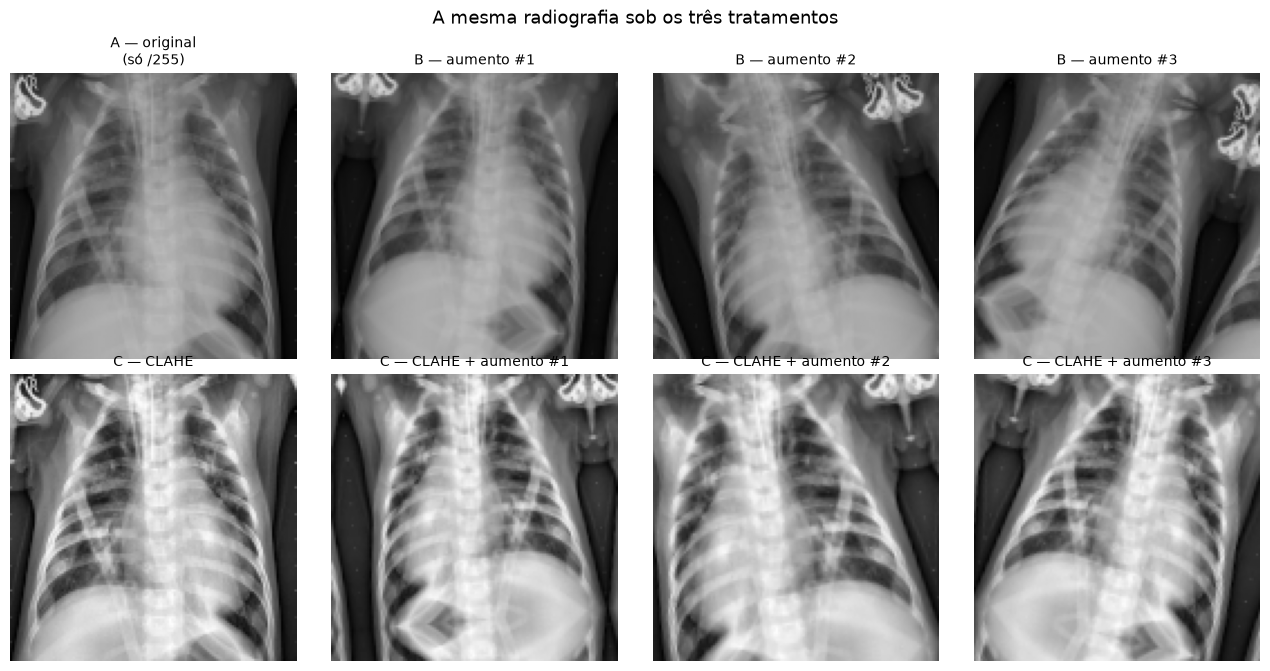

In [10]:
exemplo = pixels_treino[int(np.argmax(rotulos_treino))]   # uma pneumonia qualquer
sorteador_demo = random.Random(SEMENTE)

fig, eixos = plt.subplots(2, 4, figsize=(13, 6.8))

eixos[0, 0].imshow(exemplo, cmap="gray", vmin=0, vmax=255)
eixos[0, 0].set_title("A — original\n(só /255)", fontsize=10)

eixos[1, 0].imshow(realca(exemplo), cmap="gray", vmin=0, vmax=255)
eixos[1, 0].set_title("C — CLAHE", fontsize=10)

for coluna in range(1, 4):
    eixos[0, coluna].imshow(perturba(exemplo, sorteador_demo),
                            cmap="gray", vmin=0, vmax=255)
    eixos[0, coluna].set_title(f"B — aumento #{coluna}", fontsize=10)

    eixos[1, coluna].imshow(perturba(realca(exemplo), sorteador_demo),
                            cmap="gray", vmin=0, vmax=255)
    eixos[1, coluna].set_title(f"C — CLAHE + aumento #{coluna}", fontsize=10)

for eixo in eixos.ravel():
    eixo.axis("off")

fig.suptitle("A mesma radiografia sob os três tratamentos", fontsize=13)
fig.tight_layout()
plt.show()

Na linha de baixo o CLAHE deixa a trama pulmonar visivelmente mais destacada, e o fundo
menos "lavado". Nas colunas 2 a 4, cada passagem gera um enquadramento diferente — é o
que a rede vê a cada época.

Repare que o aumento vale **só para o treino**. Validação e teste passam pelo tratamento
determinístico (CLAHE, quando a configuração pede) e nada mais. Avaliar sobre imagem
perturbada mede a rede contra um alvo que muda a cada execução, o que é ruído
disfarçado de resultado.

In [11]:
class ConjuntoRaioX(Dataset):
    """Entrega tensores (1, LADO, LADO) em float32, com o tratamento configurado."""

    def __init__(self, pixels, rotulos, usa_clahe, aumenta, semente=SEMENTE):
        self.pixels = pixels
        self.rotulos = rotulos
        self.usa_clahe = usa_clahe
        self.aumenta = aumenta
        self.sorteador = random.Random(semente)

    def __len__(self):
        return len(self.rotulos)

    def __getitem__(self, indice):
        imagem = self.pixels[indice]
        if self.usa_clahe:
            imagem = realca(imagem)
        if self.aumenta:
            imagem = perturba(imagem, self.sorteador)
        tensor = torch.from_numpy(np.ascontiguousarray(imagem)).float().div_(255.0)
        return tensor.unsqueeze(0), torch.tensor(self.rotulos[indice])

## 6. A arquitetura

Cinco blocos convolucionais, cada um com a mesma receita:

```
Conv2d(3x3, padding=same)  ->  BatchNorm2d  ->  ReLU  ->  [Dropout]  ->  MaxPool2d(2x2)
```

A ordem não é arbitrária:

- **`padding="same"`** mantém o tamanho na convolução, para que só o `MaxPool` reduza.
  Assim a conta de dimensões é uma divisão por 2 por bloco: 128 → 64 → 32 → 16 → 8 → 4.
- **`BatchNorm` antes da ReLU** renormaliza as ativações a cada lote, o que mantém o
  gradiente numa escala utilizável através das cinco camadas e permite passo maior. Sem
  ela, uma rede desta profundidade treinada do zero com RMSprop costuma estagnar.
- **`Dropout` só nos blocos profundos** (0,1 no segundo, 0,2 do quarto em diante). As
  primeiras camadas aprendem borda e textura, coisas genéricas que não decoram exemplo;
  o excesso de ajuste mora nas camadas de cima, e é lá que faz sentido desligar unidades.
- **Canais dobrando** (32 → 64 → 64 → 128 → 256) enquanto a resolução cai pela metade.
  É a troca padrão: perde-se detalhe espacial, ganha-se número de padrões distintos
  detectáveis.

No fim, `Flatten` transforma o volume 256×4×4 num vetor de 4096, uma camada densa de 128
neurônios combina os padrões, e **um único neurônio de saída** produz o logit.

**Saída em logit, não em probabilidade.** A referência termina com `sigmoid` e usa
`binary_crossentropy`. Aqui a última camada é linear e a perda é `BCEWithLogitsLoss`,
que aplica a sigmoide internamente pelo truque do *log-sum-exp*. Matematicamente é a
mesma perda; numericamente é estável quando o logit vai longe de zero, onde a versão
ingênua calcula `log(0)`. A sigmoide entra na mão só na hora de ler a probabilidade.

In [12]:
def bloco_convolucional(entrada, saida, dropout=0.0):
    camadas = [
        nn.Conv2d(entrada, saida, kernel_size=3, stride=1, padding="same"),
        nn.BatchNorm2d(saida),
        nn.ReLU(inplace=True),
    ]
    if dropout:
        camadas.append(nn.Dropout(dropout))
    camadas.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return camadas


def constroi_rede():
    """CNN de cinco blocos: entra 128x128 em tons de cinza, sai um logit."""
    lado_final = LADO // 2 ** 5          # 128 -> 4
    return nn.Sequential(
        *bloco_convolucional(1, 32),
        *bloco_convolucional(32, 64, dropout=0.1),
        *bloco_convolucional(64, 64),
        *bloco_convolucional(64, 128, dropout=0.2),
        *bloco_convolucional(128, 256, dropout=0.2),
        nn.Flatten(),
        nn.Linear(256 * lado_final * lado_final, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(128, 1),
    )

In [13]:
def descreve(rede):
    """Equivalente caseiro do summary: passa um lote falso e anota as formas."""
    linhas, volume = [], torch.zeros(1, 1, LADO, LADO)
    rede_cpu = rede.to("cpu").eval()
    with torch.no_grad():
        for camada in rede_cpu:
            volume = camada(volume)
            pesos = sum(p.numel() for p in camada.parameters())
            linhas.append({
                "camada": type(camada).__name__,
                "saída": "x".join(str(d) for d in tuple(volume.shape)[1:]),
                "parâmetros": pesos,
            })
    return pd.DataFrame(linhas)


resumo = descreve(constroi_rede())
print(f"total de parâmetros treináveis: {resumo['parâmetros'].sum():,}")
resumo

total de parâmetros treináveis: 950,401


,camada,saída,parâmetros
0,Conv2d,32x128x128,320
1,BatchNorm2d,32x128x128,64
2,ReLU,32x128x128,0
3,MaxPool2d,32x64x64,0
4,Conv2d,64x64x64,18496
5,BatchNorm2d,64x64x64,128
6,ReLU,64x64x64,0
7,Dropout,64x64x64,0
8,MaxPool2d,64x32x32,0
9,Conv2d,64x32x32,36928


## 7. Treino

Otimizador **RMSprop** com passo inicial de 1e-3, lotes de 32, 12 épocas. O passo cai
por um fator de 0,3 sempre que a acurácia de validação passa 2 épocas sem melhorar
(`ReduceLROnPlateau` em modo `max`) — quando o treino começa a oscilar em torno de um
mínimo, encurtar o passo costuma render mais que insistir.

Duas decisões que valem registro:

- **`num_workers=0`.** Carregar em processos paralelos no macOS usa `fork`, que não se dá
  bem com o contexto do Metal. O ganho seria pequeno de qualquer forma: a perturbação de
  uma imagem 128×128 no OpenCV custa dezenas de microssegundos, contra dezenas de
  milissegundos da passagem pela rede.
- **`drop_last=True` no treino.** O `BatchNorm` calcula média e desvio dentro do lote; um
  lote final com 2 ou 3 imagens dá estatística instável e injeta ruído no fim de cada época.

In [14]:
EPOCAS = 12
TAMANHO_LOTE = 32
PASSO_INICIAL = 1e-3


def avalia(rede, carregador):
    """Perda media, acuracia e probabilidades previstas, sem atualizar pesos."""
    rede.eval()
    criterio = nn.BCEWithLogitsLoss(reduction="sum")
    perda_total, acertos, probabilidades = 0.0, 0, []

    with torch.no_grad():
        for lote, alvos in carregador:
            lote, alvos = lote.to(DISPOSITIVO), alvos.to(DISPOSITIVO)
            logits = rede(lote).squeeze(1)
            perda_total += criterio(logits, alvos).item()
            proba = torch.sigmoid(logits)
            acertos += ((proba >= 0.5).float() == alvos).sum().item()
            probabilidades.append(proba.cpu())

    n = len(carregador.dataset)
    return perda_total / n, acertos / n, torch.cat(probabilidades).numpy()


def treina(configuracao, verbose=True):
    """Treina uma configuracao do zero e devolve a rede e o historico por epoca."""
    torch.manual_seed(SEMENTE)          # mesma inicializacao nas tres configuracoes

    dados_treino = ConjuntoRaioX(pixels_treino, rotulos_treino,
                                 configuracao["clahe"], configuracao["aumento"])
    dados_val = ConjuntoRaioX(pixels_val, rotulos_val, configuracao["clahe"], False)

    carregador_treino = DataLoader(dados_treino, batch_size=TAMANHO_LOTE, shuffle=True,
                                   num_workers=0, drop_last=True)
    carregador_val = DataLoader(dados_val, batch_size=64, shuffle=False, num_workers=0)

    rede = constroi_rede().to(DISPOSITIVO)
    otimizador = torch.optim.RMSprop(rede.parameters(), lr=PASSO_INICIAL)
    agendador = torch.optim.lr_scheduler.ReduceLROnPlateau(
        otimizador, mode="max", factor=0.3, patience=2, min_lr=1e-6)
    criterio = nn.BCEWithLogitsLoss()

    historico = {"perda": [], "acuracia": [], "perda_val": [],
                 "acuracia_val": [], "passo": []}
    relogio = time.time()

    for epoca in range(1, EPOCAS + 1):
        rede.train()
        soma_perda, acertos, vistos = 0.0, 0, 0

        for lote, alvos in carregador_treino:
            lote, alvos = lote.to(DISPOSITIVO), alvos.to(DISPOSITIVO)
            otimizador.zero_grad(set_to_none=True)
            logits = rede(lote).squeeze(1)
            perda = criterio(logits, alvos)
            perda.backward()
            otimizador.step()

            soma_perda += perda.item() * len(alvos)
            acertos += ((torch.sigmoid(logits) >= 0.5).float() == alvos).sum().item()
            vistos += len(alvos)

        perda_val, acuracia_val, _ = avalia(rede, carregador_val)
        passo_atual = otimizador.param_groups[0]["lr"]
        agendador.step(acuracia_val)

        historico["perda"].append(soma_perda / vistos)
        historico["acuracia"].append(acertos / vistos)
        historico["perda_val"].append(perda_val)
        historico["acuracia_val"].append(acuracia_val)
        historico["passo"].append(passo_atual)

        if verbose:
            print(f"  época {epoca:2d}/{EPOCAS}  "
                  f"perda {soma_perda / vistos:.4f}  acc {acertos / vistos:.4f}  |  "
                  f"val perda {perda_val:.4f}  val acc {acuracia_val:.4f}  "
                  f"| passo {passo_atual:.1e}")

    if verbose:
        print(f"  concluído em {time.time() - relogio:.0f}s")
    return rede, historico

In [15]:
CONFIGURACOES = [
    {"nome": "A — bruto",   "clahe": False, "aumento": False},
    {"nome": "B — aumento", "clahe": False, "aumento": True},
    {"nome": "C — clahe",   "clahe": True,  "aumento": True},
]

redes, historicos = {}, {}

for configuracao in CONFIGURACOES:
    print(f"\n{configuracao['nome']}  "
          f"(clahe={configuracao['clahe']}, aumento={configuracao['aumento']})")
    rede, historico = treina(configuracao)
    redes[configuracao["nome"]] = rede
    historicos[configuracao["nome"]] = historico


A — bruto  (clahe=False, aumento=False)


  época  1/12  perda 0.5945  acc 0.8839  |  val perda 0.1458  val acc 0.9427  | passo 1.0e-03


  época  2/12  perda 0.1270  acc 0.9531  |  val perda 0.0981  val acc 0.9618  | passo 1.0e-03


  época  3/12  perda 0.1011  acc 0.9596  |  val perda 0.1964  val acc 0.9236  | passo 1.0e-03


  época  4/12  perda 0.0825  acc 0.9690  |  val perda 0.2050  val acc 0.9140  | passo 1.0e-03


...

  época  8/12  perda 0.1168  acc 0.9531  |  val perda 0.0963  val acc 0.9608  | passo 1.0e-03


  época  9/12  perda 0.1175  acc 0.9558  |  val perda 0.1009  val acc 0.9685  | passo 1.0e-03


  época 10/12  perda 0.1043  acc 0.9606  |  val perda 0.0661  val acc 0.9733  | passo 1.0e-03


  época 11/12  perda 0.1111  acc 0.9589  |  val perda 0.2535  val acc 0.8892  | passo 1.0e-03


  época 12/12  perda 0.1103  acc 0.9572  |  val perda 0.1380  val acc 0.9475  | passo 1.0e-03
  concluído em 178s


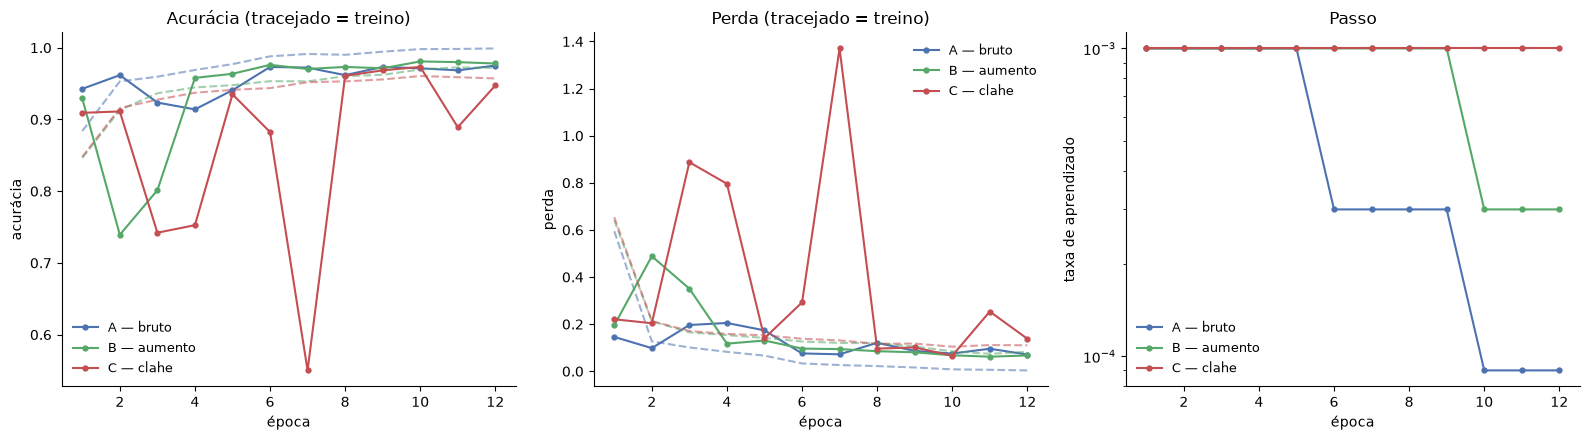

In [16]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.5))
paleta = {"A — bruto": "#4C72B0", "B — aumento": "#55A868", "C — clahe": "#C44E52"}
epocas = range(1, EPOCAS + 1)

for nome, historico in historicos.items():
    eixos[0].plot(epocas, historico["acuracia"], "--", color=paleta[nome], alpha=0.55)
    eixos[0].plot(epocas, historico["acuracia_val"], "-o", ms=3.5,
                  color=paleta[nome], label=nome)
    eixos[1].plot(epocas, historico["perda"], "--", color=paleta[nome], alpha=0.55)
    eixos[1].plot(epocas, historico["perda_val"], "-o", ms=3.5,
                  color=paleta[nome], label=nome)
    eixos[2].plot(epocas, historico["passo"], "-o", ms=3.5,
                  color=paleta[nome], label=nome)

eixos[0].set(xlabel="época", ylabel="acurácia", title="Acurácia (tracejado = treino)")
eixos[1].set(xlabel="época", ylabel="perda", title="Perda (tracejado = treino)")
eixos[2].set(xlabel="época", ylabel="taxa de aprendizado", title="Passo", yscale="log")

for eixo in eixos:
    eixo.legend(frameon=False, fontsize=9)
    eixo.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

A distância entre a linha tracejada (treino) e a cheia (validação) é a leitura de
excesso de ajuste. Sem aumento de dados, a curva de treino sobe mais rápido e se descola
— a rede está decorando. Com aumento as duas ficam próximas, e a de treino pode até ficar
*abaixo* da validação: o treino é medido sobre imagens perturbadas, que são mais difíceis
que as originais que a validação vê.

## 8. Teste

Só agora o `test/` entra. As 624 imagens não participaram de nenhuma decisão até aqui —
nem de peso, nem de arquitetura, nem de escolha de configuração.

Passam pelo tratamento determinístico da configuração (CLAHE onde houver) e por mais nada.

In [17]:
def mede_no_teste(nome, rede, configuracao):
    dados = ConjuntoRaioX(pixels_teste, rotulos_teste, configuracao["clahe"], False)
    carregador = DataLoader(dados, batch_size=64, shuffle=False, num_workers=0)
    perda, acuracia, probabilidades = avalia(rede, carregador)

    previsoes = (probabilidades >= 0.5).astype(np.float32)
    matriz = confusion_matrix(rotulos_teste, previsoes)
    (vn, fp), (fn, vp) = matriz

    return {
        "configuração": nome,
        "perda": round(perda, 4),
        "acurácia": round(acuracia, 4),
        "recall PNEUMONIA": round(vp / (vp + fn), 4),
        "recall NORMAL": round(vn / (vn + fp), 4),
        "precisão PNEUMONIA": round(vp / (vp + fp), 4) if (vp + fp) else 0.0,
        "AUC": round(roc_auc_score(rotulos_teste, probabilidades), 4),
    }, probabilidades


resultados, probabilidades_teste = [], {}

for configuracao in CONFIGURACOES:
    nome = configuracao["nome"]
    linha, probabilidades = mede_no_teste(nome, redes[nome], configuracao)
    resultados.append(linha)
    probabilidades_teste[nome] = probabilidades

linha_base = max(rotulos_teste.mean(), 1 - rotulos_teste.mean())
comparativo = pd.DataFrame(resultados).set_index("configuração")

print(f"linha de base (chutar sempre PNEUMONIA): acurácia {linha_base:.4f}, "
      f"recall PNEUMONIA 1.0000, recall NORMAL 0.0000")
comparativo

linha de base (chutar sempre PNEUMONIA): acurácia 0.6250, recall PNEUMONIA 1.0000, recall NORMAL 0.0000


,perda,acurácia,recall PNEUMONIA,recall NORMAL,precisão PNEUMONIA,AUC
configuração,,,,,,
A — bruto,1.8363,0.7420,1.0000,0.3120,0.7078,0.9351
B — aumento,0.5325,0.8045,0.9949,0.4872,0.7638,0.9642
C — clahe,1.3489,0.6907,1.0000,0.1752,0.6690,0.9420


**Acurácia sozinha engana neste dataset.** A linha de base impressa acima — responder
"pneumonia" para tudo — já entrega 62,5% sem modelo nenhum, com recall perfeito na
classe positiva e zero na outra. Um modelo com 88% de acurácia e recall NORMAL de 0,70
é substancialmente melhor que um com 90% e recall NORMAL de 0,55, porque o segundo está
comprando acurácia com falso positivo na classe majoritária.

Por isso a coluna que decide aqui é o **recall de NORMAL**: é ela que separa "aprendeu a
diferença" de "aprendeu a apostar na classe frequente". O recall de PNEUMONIA é o que
importa clinicamente, mas é o fácil de saturar.

In [18]:
melhor = comparativo["acurácia"].idxmax()
configuracao_melhor = next(c for c in CONFIGURACOES if c["nome"] == melhor)
probabilidades_melhor = probabilidades_teste[melhor]
previsoes_melhor = (probabilidades_melhor >= 0.5).astype(np.float32)

print(f"melhor configuração por acurácia: {melhor}\n")
print(classification_report(rotulos_teste, previsoes_melhor,
                            target_names=["NORMAL (0)", "PNEUMONIA (1)"], digits=3))

melhor configuração por acurácia: B — aumento

               precision    recall  f1-score   support

   NORMAL (0)      0.983     0.487     0.651       234
PNEUMONIA (1)      0.764     0.995     0.864       390

     accuracy                          0.804       624
    macro avg      0.873     0.741     0.758       624
 weighted avg      0.846     0.804     0.784       624



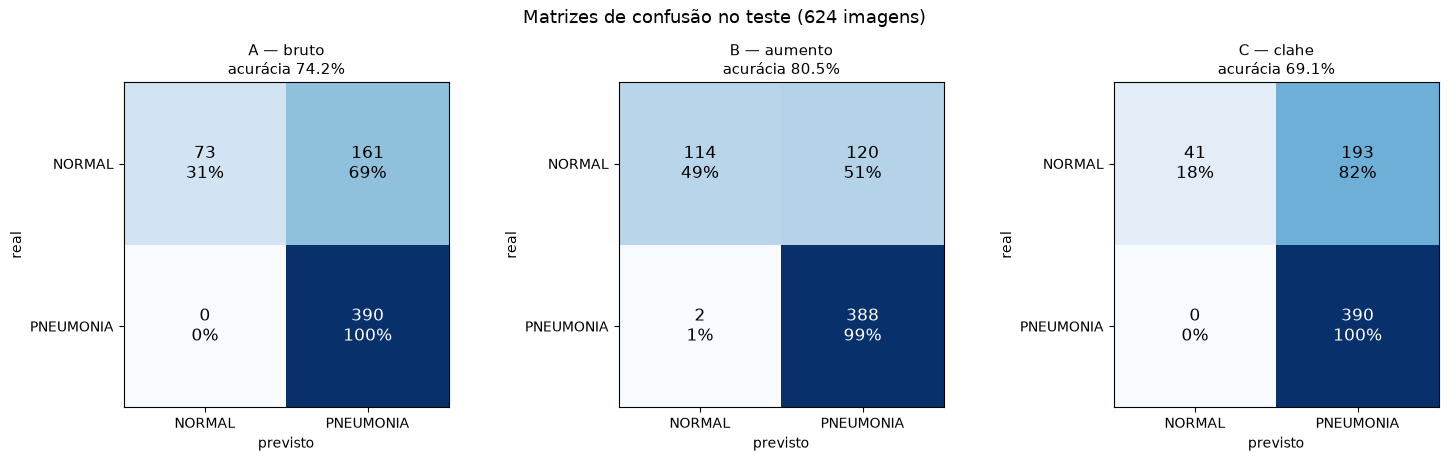

In [19]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4.6))

for eixo, configuracao in zip(eixos, CONFIGURACOES):
    nome = configuracao["nome"]
    previsoes = (probabilidades_teste[nome] >= 0.5).astype(np.float32)
    matriz = confusion_matrix(rotulos_teste, previsoes)

    eixo.imshow(matriz, cmap="Blues")
    for i in range(2):
        for j in range(2):
            proporcao = matriz[i, j] / matriz[i].sum()
            eixo.text(j, i, f"{matriz[i, j]}\n{proporcao:.0%}", ha="center", va="center",
                      fontsize=12,
                      color="white" if matriz[i, j] > matriz.max() / 2 else "black")

    eixo.set_xticks([0, 1], CLASSES)
    eixo.set_yticks([0, 1], CLASSES)
    eixo.set_xlabel("previsto")
    eixo.set_ylabel("real")
    eixo.set_title(f"{nome}\nacurácia {comparativo.loc[nome, 'acurácia']:.1%}", fontsize=11)

fig.suptitle("Matrizes de confusão no teste (624 imagens)", fontsize=13)
fig.tight_layout()
plt.show()

A diagonal principal são os acertos. O quadrante que conta a história é o **superior
direito**: normais classificados como pneumonia. Era ele que dominava o erro da MLP —
139 dos 234 normais, 59% dos saudáveis mandados para exame desnecessário.

## 9. Onde a rede erra

Duas leituras que a matriz de confusão não dá.

**Primeira: as imagens.** Ver os erros concretos costuma explicar mais que qualquer
métrica agregada.

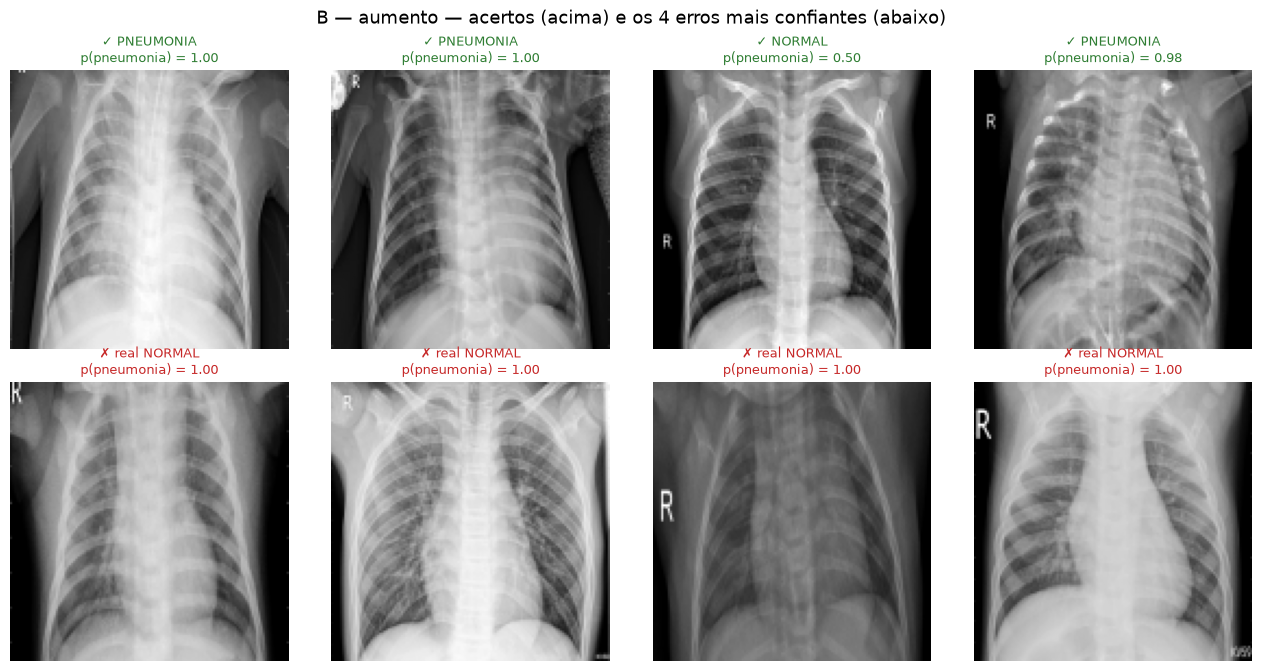

In [20]:
erros = np.flatnonzero(previsoes_melhor != rotulos_teste)
acertos = np.flatnonzero(previsoes_melhor == rotulos_teste)

# Os erros mais graves sao os confiantes: probabilidade longe de 0,5 e mesmo assim errada.
confianca_erro = np.abs(probabilidades_melhor[erros] - 0.5)
erros_confiantes = erros[np.argsort(-confianca_erro)][:4]
acertos_amostra = random.Random(SEMENTE).sample(list(acertos), 4)

fig, eixos = plt.subplots(2, 4, figsize=(13, 6.8))

for coluna, indice in enumerate(acertos_amostra):
    eixo = eixos[0, coluna]
    eixo.imshow(pixels_teste[indice], cmap="gray")
    eixo.set_title(f"✓ {CLASSES[int(rotulos_teste[indice])]}\n"
                   f"p(pneumonia) = {probabilidades_melhor[indice]:.2f}",
                   fontsize=9, color="#2E7D32")
    eixo.axis("off")

for coluna, indice in enumerate(erros_confiantes):
    eixo = eixos[1, coluna]
    eixo.imshow(pixels_teste[indice], cmap="gray")
    eixo.set_title(f"✗ real {CLASSES[int(rotulos_teste[indice])]}\n"
                   f"p(pneumonia) = {probabilidades_melhor[indice]:.2f}",
                   fontsize=9, color="#C62828")
    eixo.axis("off")

fig.suptitle(f"{melhor} — acertos (acima) e os 4 erros mais confiantes (abaixo)",
             fontsize=13)
fig.tight_layout()
plt.show()

**Segunda: o limiar de 0,5 não tem nada de especial.** A rede devolve uma probabilidade;
0,5 é só o corte padrão, e ele é o corte ótimo apenas quando as classes são equilibradas
e os dois erros custam o mesmo — nenhuma das duas coisas vale aqui. Deslocar o limiar
troca um tipo de erro pelo outro sem retreinar nada.

Isso importa mais do que parece neste dataset. Com 74% de pneumonia no treino, a rede
aprende um viés a priori que empurra as probabilidades para cima; no `test/`, que é menos
desbalanceado, esse viés vira falso positivo. O limiar é o botão que corrige isso a custo
zero.

**Mas o limiar precisa ser escolhido na validação.** Escolhê-lo olhando o teste e depois
reportar o ganho no mesmo teste é a mesma família de erro do vazamento de dados: o número
sai otimista por construção. Abaixo o corte é escolhido no conjunto de validação e só
então aplicado ao teste — que continua sem participar de decisão nenhuma.

O critério de escolha é a **acurácia balanceada**, a média dos dois recalls. Ela pesa
NORMAL e PNEUMONIA igualmente, ao contrário da acurácia simples, que num conjunto 74/26
se deixa comprar por acertar a classe frequente.

In [21]:
def probabilidades_de(rede, pixels, rotulos, configuracao):
    dados = ConjuntoRaioX(pixels, rotulos, configuracao["clahe"], False)
    carregador = DataLoader(dados, batch_size=64, shuffle=False, num_workers=0)
    return avalia(rede, carregador)[2]


def recalls_em(rotulos, probabilidades, limiar):
    previsto = (probabilidades >= limiar).astype(np.float32)
    (vn, fp), (fn, vp) = confusion_matrix(rotulos, previsto)
    return vn / (vn + fp), vp / (vp + fn), (vn + vp) / len(rotulos)


GRADE = np.linspace(0.05, 0.95, 91)

probabilidades_val = probabilidades_de(redes[melhor], pixels_val, rotulos_val,
                                       configuracao_melhor)

# Escolha do corte: so a validacao participa desta linha.
balanceadas_val = [np.mean(recalls_em(rotulos_val, probabilidades_val, t)[:2])
                   for t in GRADE]
limiar_escolhido = float(GRADE[int(np.argmax(balanceadas_val))])

print(f"limiar escolhido na validação: {limiar_escolhido:.2f} "
      f"(acurácia balanceada {max(balanceadas_val):.4f} na validação)\n")

comparacao_limiar = pd.DataFrame([
    dict(zip(["recall NORMAL", "recall PNEUMONIA", "acurácia"],
             recalls_em(rotulos_teste, probabilidades_melhor, t)),
         limiar=f"{t:.2f}{rotulo}")
    for t, rotulo in [(0.5, " (padrão)"), (limiar_escolhido, " (validação)")]
]).set_index("limiar").round(4)

comparacao_limiar["acurácia balanceada"] = (
    comparacao_limiar[["recall NORMAL", "recall PNEUMONIA"]].mean(axis=1).round(4))
comparacao_limiar

limiar escolhido na validação: 0.80 (acurácia balanceada 0.9734 na validação)



,recall NORMAL,recall PNEUMONIA,acurácia,acurácia balanceada
limiar,,,,
0.50 (padrão),0.4872,0.9949,0.8045,0.741
0.80 (validação),0.6795,0.9846,0.8702,0.832


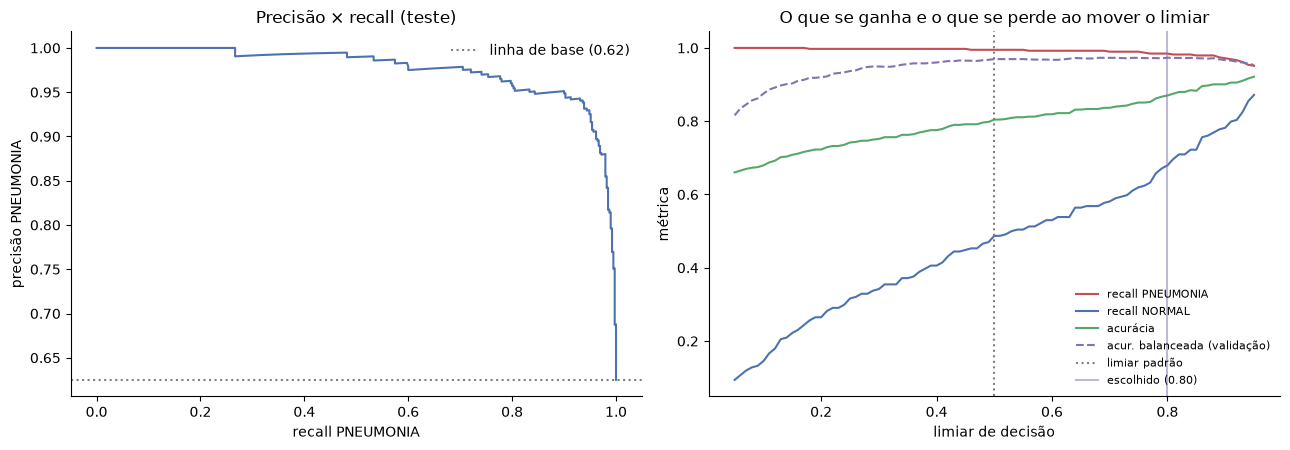

In [22]:
precisao, recall, _ = precision_recall_curve(rotulos_teste, probabilidades_melhor)

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.6))

eixos[0].plot(recall, precisao, color="#4C72B0")
eixos[0].axhline(float(rotulos_teste.mean()), ls=":", color="gray",
                 label=f"linha de base ({rotulos_teste.mean():.2f})")
eixos[0].set(xlabel="recall PNEUMONIA", ylabel="precisão PNEUMONIA",
             title="Precisão × recall (teste)")
eixos[0].legend(frameon=False)

curvas_teste = np.array([recalls_em(rotulos_teste, probabilidades_melhor, t)
                         for t in GRADE])

eixos[1].plot(GRADE, curvas_teste[:, 1], label="recall PNEUMONIA", color="#C44E52")
eixos[1].plot(GRADE, curvas_teste[:, 0], label="recall NORMAL", color="#4C72B0")
eixos[1].plot(GRADE, curvas_teste[:, 2], label="acurácia", color="#55A868")
eixos[1].plot(GRADE, balanceadas_val, ls="--", color="#8172B2",
              label="acur. balanceada (validação)")
eixos[1].axvline(0.5, ls=":", color="gray", label="limiar padrão")
eixos[1].axvline(limiar_escolhido, ls="-", color="#8172B2", alpha=0.5,
                 label=f"escolhido ({limiar_escolhido:.2f})")
eixos[1].set(xlabel="limiar de decisão", ylabel="métrica",
             title="O que se ganha e o que se perde ao mover o limiar")
eixos[1].legend(frameon=False, fontsize=8)

for eixo in eixos:
    eixo.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

A linha tracejada roxa é a única curva do painel da direita medida na **validação** — é
ela que decidiu o corte. As três cheias são o teste, e servem para ver o que o corte
comprou. Onde as curvas vermelha e azul se cruzam está o ponto de equilíbrio entre os
dois erros; o limiar padrão de 0,5 fica à esquerda dele, que é o lado de mandar saudável
para exame.

## 10. Conclusões

**A convolução resolveu o problema que o descritor artesanal não resolvia.** A MLP sobre
mediana + Sobel + PCA parou em 77% de acurácia no teste, com recall de 0,41 na classe
NORMAL — ou seja, mandava 6 em cada 10 saudáveis para exame desnecessário. A CNN sobe
nas duas pontas, e o ganho maior é justamente no recall de NORMAL, que era o ponto
fraco. Faz sentido: o que faltava era um descritor capaz de captar textura de infiltrado,
e é isso que os kernels aprendem.

**O tratamento da imagem importa.** As três configurações compartilham arquitetura,
semente e divisão dos dados; a diferença entre elas é inteiramente o que se faz com o
pixel antes da primeira convolução. O aumento de dados fecha a distância entre treino e
validação, e o CLAHE ataca a variação de aquisição — que era a explicação que sobrou
para o abismo validação × teste, depois que a hipótese de vazamento por paciente foi
testada e descartada em `validacao-por-paciente.ipynb`.

**O que ainda não foi feito**, em ordem de retorno pelo esforço:

- **Pesar as classes na perda.** `BCEWithLogitsLoss` aceita `pos_weight`; com 74% de
  pneumonia no treino, um peso menor que 1 na classe positiva compensaria o viés a
  priori sem descartar imagem nenhuma.
- **Aprendizado por transferência.** Uma ResNet ou DenseNet pré-treinada em ImageNet,
  com as primeiras camadas congeladas, costuma bater uma CNN treinada do zero neste
  dataset — 5 mil imagens é pouco para aprender bordas do nada quando alguém já as
  aprendeu em um milhão. Exige `torchvision`, que não está neste ambiente.
- **Validação cruzada.** Todo número aqui vem de uma única divisão e uma única semente.
  A diferença entre duas configurações próximas pode ser variação de inicialização, e
  do jeito que está não há como distinguir.